In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime as dt
import random
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore
import numpy as np, pandas as pd
from tqdm import tqdm
# Custom functions for alpha calculations
import importlib.util
import sys
from WorldQuant_alpha101_code.alphas import *
from WorldQuant_alpha101_code.test_alphas import *

# configs
CLIPPING_VALUE = 1e6
RANDOM_SEED = 42
HORIZON = 20

#### Part 0: Obtaining stock data

In [2]:
tickers = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV']
industries = {'XLB': 'Buildings',
             'XLE': 'Energy',
             'XLF': 'Financials',
             'XLI': 'Industrials',
             'XLK': 'Technology',
             'XLP': 'Consumer Staples',
             'XLU': 'Utilities',
             'XLV': 'Healthcare'
             }
start_date = dt.datetime(2000,1,1)
end_date = dt.datetime(2025,10,1)

stock_data = yf.download(tickers, start_date, end_date,auto_adjust=False)
tickers = stock_data['Close'].columns.tolist()

[*********************100%***********************]  8 of 8 completed


In [3]:
stock_data = stock_data.drop(columns=['Close']).rename(columns={'Adj Close':'Close'})

In [4]:
# Calculate returns for each ticker separately
returns = stock_data['Close'].pct_change()

# Add as new top-level column
for ticker in stock_data['Close'].columns:
    stock_data[('Returns', ticker)] = returns[ticker]

In [5]:
nav_dict = {}
for ticker in tickers:
    df = pd.read_excel(f'ETF data/navhist-us-en-{ticker.lower()}.xlsx',
                                     skiprows=3)
    df = df[['Date','Shares Outstanding']]
    df = df[~(df['Shares Outstanding'].isnull()) & ~(df['Shares Outstanding']=='-')]
    df['Date'] = pd.to_datetime(df['Date'])
    df['Shares Outstanding'] = df['Shares Outstanding'].astype(float)
    df = df.set_index('Date')

    nav_dict[ticker] = df.sort_index(ascending=True).copy()

In [6]:
# nav_dict['XLP'][nav_dict['XLP'].columns[3]]
# df = nav_dict['XLP']

# df

In [7]:
for ticker, df in nav_dict.items():
    stock_data[('Shares Outstanding', ticker)] = df['Shares Outstanding']
stock_data['Close']

Ticker,XLB,XLE,XLF,XLI,XLK,XLP,XLU,XLV
Date,,,,,,,,
2000-01-03,14.595760,13.513031,11.186873,18.187742,41.366726,12.305084,11.186380,20.612177
2000-01-04,14.455250,13.258662,10.697836,17.685261,39.268074,11.958583,10.848945,20.144451
2000-01-05,15.052435,13.608415,10.613776,17.606441,38.685097,12.169868,11.122712,19.963730
2000-01-06,15.438834,14.133036,11.079902,17.842907,37.402599,12.398050,11.103614,20.027508
2000-01-07,15.430059,14.284066,11.263290,18.522734,38.055504,13.184012,11.199115,20.272013
...,...,...,...,...,...,...,...,...
2025-09-24,88.980003,90.339996,53.610001,152.250000,278.489990,78.519997,86.250000,136.389999
2025-09-25,87.820000,91.150002,53.470001,151.220001,278.000000,77.769997,85.419998,134.130005
2025-09-26,88.839996,91.989998,53.860001,152.580002,278.839996,77.959999,86.809998,135.500000


In [8]:
for ticker in tickers:
    stock_data[('Market_Cap', ticker)] = stock_data[('Close', ticker)] * stock_data[('Shares Outstanding', ticker)]
stock_data = stock_data.dropna(subset=[('Market_Cap', ticker) for ticker in tickers], how='all')

#### Part 1: Factor construction

Start with raw stock data. Compute 82 of 101 alphas

- Core Alpha101-style technical factors

In [9]:
Alphas = Alphas(stock_data)

### Dealing with NaNs in Alphas
#### Source of NaNs
a. Rolling window
    - these occur when there is a rolling window that results in NaNs at the start of the alpha created

b. Systematic NaNs
    - these occur due to systematic computation of the formula that results in NaNs happening sporadically. 
    - Need to further investigate these

In [10]:
# factor application function
def build_factor_table(stock_data, alpha_methods, alphas_instance, industry_map, gap=1, horizon=21):
    """Build a long-format factor table.

    Compute specified alpha series, concatenate into a long DataFrame (date, ticker),
    attach market capitalization and industry, and compute forward returns
    using `gap` and `horizon`.

    Inputs:
        stock_data (pd.DataFrame): price/metrics panel with MultiIndex columns
            like ('Close', ticker) and ('Market_Cap', ticker).
        alpha_methods (iterable[str]): names of alpha methods to call on
            alphas_instance (e.g. ['alpha001', 'alpha050']).
        alphas_instance (object): instance or class exposing alpha methods that
            return DataFrame (dates x tickers).
        industry_map (dict): mapping {ticker: industry_name}.
        gap (int): days to skip before the forward-return window (default 1).
        horizon (int): forward-return window length in days (default 21).

    Returns:
        pd.DataFrame: index (date, ticker) with alpha columns, 'market_cap', 'industry', 'forward_return'.
    """
    CLIPPING_VALUE = 1e6
    #  ---------- Step 1: Get Alphas ----------
    factors = []

    print(f"Calculating Alphas...")
    for method_name in tqdm(alpha_methods, desc='Calculating Alphas per factor '):
        try:
            alpha_func = getattr(alphas_instance, method_name)
            alpha_df = alpha_func()

            # Clip to avoid exploding values
            alpha_df = alpha_df.clip(lower=-CLIPPING_VALUE, upper=CLIPPING_VALUE)
            alpha_df = alpha_df.replace([np.inf, -np.inf], np.nan).fillna(0)

            # Flatten MultiIndex (date, stock) into Series
            alpha_series = alpha_df.stack().rename(method_name)
            factors.append(alpha_series)

        except Exception as e:
            print(f"❌ {method_name} failed: {e}")
    print(f"Alphas done.")
    # Combine all alpha factors into one DataFrame
    factors_df = pd.concat(factors, axis=1)

    print(f"Final factors_df shape: {factors_df.shape}")

    # ---------- Step 2: Add Market Cap and Industry ----------
    factors_df['market_cap'] = stock_data['Market_Cap'].stack()
    factors_df['industry'] = factors_df.index.get_level_values('Ticker').map(industry_map)

    # ---------- Step 3: Compute forward returns ----------
    factors_df['forward_return'] = (stock_data['Close'].shift(-(gap + horizon)) / 
                                            stock_data['Close'].shift(-gap) - 1).stack()

    # ---------- Step 4: Keep only indexes that are available for all these ----------
    factors_df = factors_df.dropna(how="any", subset=alpha_methods + ['market_cap', 'forward_return'])
    
    factors_df = factors_df.sort_index()

    return factors_df

# List all alpha methods in the Alphas class
alpha_methods = \
[method for method in dir(Alphas) 
            if method.startswith('alpha') and method[5:].isdigit()]
    

In [11]:
factor_table = build_factor_table(stock_data, alpha_methods, Alphas, industries, horizon=HORIZON)
                                                                            # changed horizon to 1 day to match Du paper                                                            

Calculating Alphas...


Calculating Alphas per factor :  76%|███████▌  | 62/82 [00:32<00:10,  1.97it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
Calculating Alphas per factor : 100%|██████████| 82/82 [01:17<00:00,  1.05it/s]


Alphas done.
Final factors_df shape: (38920, 82)


In [12]:
factor_table['forward_return'].describe()

count    38752.000000
mean         0.008716
std          0.056334
min         -0.562808
25%         -0.017807
50%          0.012609
75%          0.039291
max          0.583689
Name: forward_return, dtype: float64

Notes:
- Market capitalisation is included in the data pipeline even though it itself is not an alpha factor. Market cap represents firm size, which is one of the strongest systematic risk factors in asset pricing.
- If size is not controlled for, many factors will simply be disguised size effects (e.g. if momentum or liquidity factor loads heavily on small caps, it looks predictive, but the model would simply be leaning into the size bias - small caps having higher vol, higher momentum and lower liquidity).
- The eventual size neutralization in the pipeline is: Regressing each factor on log(MarketCap) and (log(MarketCap))<sup>2</sup> per date, then using residuals as the pure alpha.

# Measure baseline IC
## Function to compute information coefficient


In [13]:
def compute_ic(table, factor_col, forward_return_col='forward_return', method='spearman'):
    """
    Compute the Information Coefficient (IC) per date.

    The IC is the cross-sectional correlation between factor values and 
    forward returns for each date. It measures how well the factor predicts returns.

    Parameters
    ----------
    table : pd.DataFrame
        Must contain 'Date', factor_col, and forward_return_col columns.
    factor_col : str
        Column name of the (possibly neutralized) factor.
    forward_return_col : str, default='forward_return'
        Column name of forward returns.
    method : {'pearson', 'spearman'}, default='pearson'
        Correlation method to use.

    Returns
    -------
    pd.Series
        Series of IC values indexed by date.
    # """
    ic_series = {}
    for dt, s in table.groupby('Date'):
        s = s[[factor_col, forward_return_col]].dropna()
        if len(s) < 5:
            print(f"Not enough data to compute IC for date {dt}. Required at least 5, got {len(s)}.")
            ic_series[dt] = np.nan
            continue
        
        # Check if either column has zero variance
        if s[factor_col].std() == 0:
            print(f"Zero variance in factor '{factor_col}' on date {dt}. Cannot compute IC.")
            ic_series[dt] = np.nan
            continue
            
        if method == 'spearman':
            rho = s[factor_col].rank().corr(s[forward_return_col].rank())
        else:
            rho = s[factor_col].corr(s[forward_return_col])
        ic_series[dt] = rho
    return pd.Series(ic_series).sort_index()


In [14]:
ic_list = [
    compute_ic(factor_table.reset_index(), col, method='spearman') \
                    for col in tqdm(alpha_methods, desc='Computing ICs per factor ')
                    ]
ic_df = pd.concat(ic_list, axis=1)
ic_df.isnull().sum().sort_values().tail(10)

Computing ICs per factor :   0%|          | 0/82 [00:00<?, ?it/s]

Zero variance in factor 'alpha001' on date 2006-05-31 00:00:00. Cannot compute IC.


Computing ICs per factor :   1%|          | 1/82 [00:02<02:56,  2.18s/it]

Zero variance in factor 'alpha002' on date 2006-05-31 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha002' on date 2006-06-01 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha002' on date 2006-06-02 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha002' on date 2006-06-05 00:00:00. Cannot compute IC.


Computing ICs per factor :   2%|▏         | 2/82 [00:04<02:49,  2.12s/it]

...

Zero variance in factor 'alpha099' on date 2006-05-31 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-01 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-02 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-05 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-06 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-07 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-08 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-09 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-12 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-13 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-14 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2006-06-15 00:00:00. Cannot compute IC.
Zero

Computing ICs per factor :  99%|█████████▉| 81/82 [02:52<00:02,  2.05s/it]

Zero variance in factor 'alpha099' on date 2025-02-03 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-04 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-05 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-06 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-07 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-10 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-02-11 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-03-04 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-03-06 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-03-13 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-03-14 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099' on date 2025-03-17 00:00:00. Cannot compute IC.
Zero

Computing ICs per factor : 100%|██████████| 82/82 [02:54<00:00,  2.13s/it]


57     533
68     565
45     686
59     749
6      784
56     841
20    1315
77    4842
61    4844
73    4844
dtype: int64

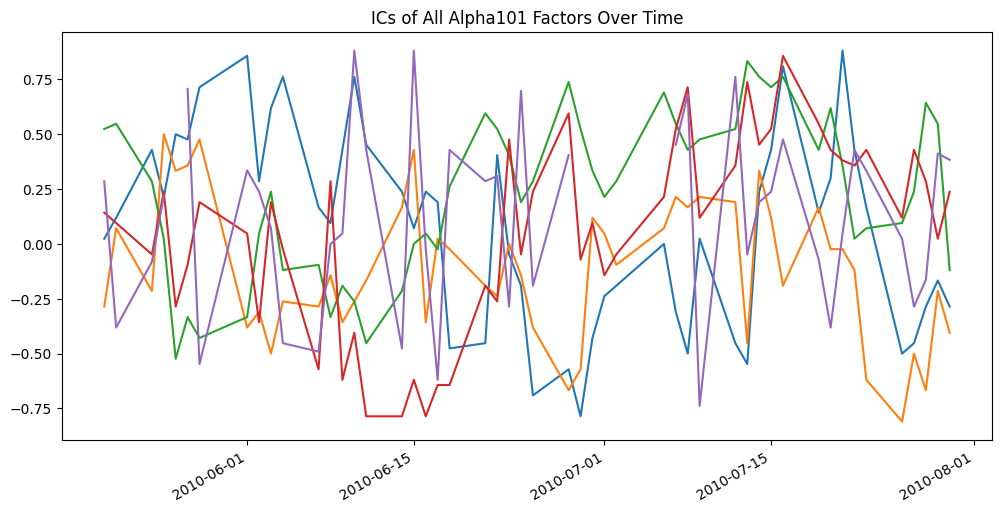

In [15]:
ic_df.iloc[1000:1050][ic_df.columns[random.sample(range(ic_df.shape[1]),5)]]\
    .plot(legend=False, 
          figsize=(12,6), 
          title='ICs of All Alpha101 Factors Over Time');

In [16]:
ic_df.columns = alpha_methods

In [17]:
nan_id_columns = ic_df.columns[np.where(ic_df.isnull().sum() > 1000)].to_list()
nan_id_columns

['alpha021', 'alpha068', 'alpha086', 'alpha095']

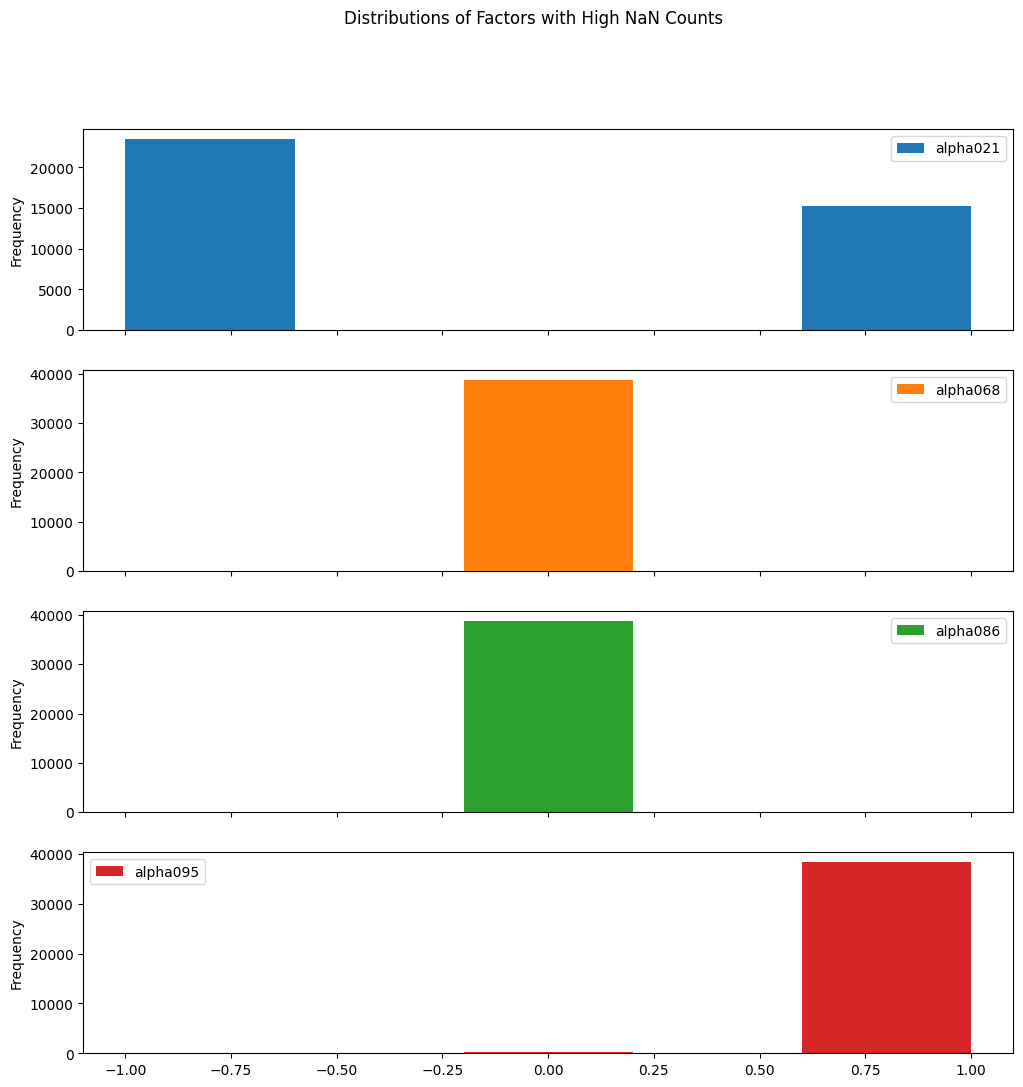

In [18]:
factor_table[nan_id_columns].plot(
    kind='hist', 
    bins=5, 
    figsize=(12, 12),  # You might want to increase figsize to accomm/odate more plots
    title='Distributions of Factors with High NaN Counts', 
    subplots=True,
);

#### interogate the alpha and find why there is so little data info 


    alpha021 - Bollinger Band + Volume hybrid strategy \
    alpha027 - \
    alpha068 - mean reversion. requires correlation \ 
    alpha086 - compares price-volume correlation trends against intraday price positioning. The multiply by -1 means negative values = buy signals. \
    alpha095 - Contrarian setup: Underperforming stocks with building volume-price conviction. Very infrequent occurance

    alpha 21 an 27 have enough spread to have long short info, alpha 95 also has some differing signals 

In [19]:
alpha_methods.remove('alpha068')
alpha_methods.remove('alpha086')

In [20]:
ic_df = ic_df[alpha_methods]
ic_df.shape

(4844, 80)

#### Part 3: Bias correction / neutralisation

Raw factors are not pure predictors, they often capture structural biases like:

- Industry effects (tech stocks move together)

- Size effects (small caps have higher volatility)

- Market-wide trends (momentum correlates with beta)

Neutralization ensures your factor’s correlation with forward returns isn’t just due to those broad effects.

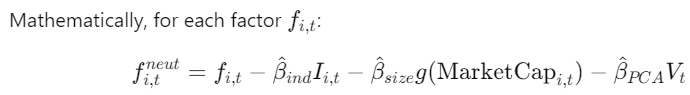

Stage 1. Identify systematic risk factors (via PCA)

Compute correlation matrix of factors.

Extract top K eigenvectors (principal components) representing “market-wide” common movements.

Optional: project factors orthogonally to remove those common components:
​
![image.png](attachment:ed279968-c4f5-4c21-b302-50b718d4710c.png)

Stage 2: Industry neutralisation

Regress each factor cross-sectionally on industry dummy variables:

![image.png](attachment:dde99fde-80d3-420e-8ff6-a12678a4b7fc.png)

Use robust regression (e.g., Huber, ridge) to avoid outlier distortion.

Stage 3: Size neutralisation (market cap bias)

Fit a log-linear model to remove linear and quadratic size effects

Stage 4: Adaptive neutralisation strength

In high-volatility regimes, use stronger neutralization (Du eq. 8):

![image.png](attachment:cc901f04-7497-40fb-9ca0-2b356a48c1cb.png)

Stage 5: Standardisation

After all neutralisation: Cross-sectionally z-score each factor (mean 0, std 1 per day).
This ensures no factor dominates due to scale.

In [21]:
# Neutralisation function
def neutralize_cross_sectional(table, factor_cols, industry_col='industry', cap_col='market_cap', variance_threshold=0.95, ridge_alpha=1.0):
    """
    table: long-format df with columns ['date','ticker', factor_cols..., industry_col, cap_col]
    factor_cols: list of factor column names to neutralize
    variance_threshold: the amount of variance to explain via PCA, e.g., 0.95 means 95% variance
    steps:
      1) for each date, create cross-sectional matrix F (n_stocks x n_factors)
      2) optional: PCA decomposition on F (correlation or covariance) and remove projection onto components that explain the desired variance threshold
      3) industry neutralization: regress each factor on industry dummies (ridge) and subtract predicted
      4) size neutralization: regress residual on log(market_cap) and (log(market_cap))^2
      5) z-score each factor cross-sectionally (per date)
    returns: table with neutralized factor columns appended as e.g. mom12_neut
    """
    out_rows = []
    dates = table['Date'].unique()
    
    for dt in tqdm(dates, desc='Neutralizing per date'):
        slice_df = table[table['Date'] == dt].copy()
        # Build factor matrix F (n_stocks x m_factors)
        F = slice_df[factor_cols].values

        # --- PCA removal based on variance threshold or no. of components ---
        if variance_threshold is not None and variance_threshold > 0:
            # Standardize the factors (columns mean=0, variance=1)
            scaler = StandardScaler(with_mean=True, with_std=True)
            Fc = scaler.fit_transform(F)
            
            # Perform PCA and get explained variance ratio
            pca = PCA()
            pca.fit(Fc)
            explained_variance_ratio = pca.explained_variance_ratio_

            ## Find the number of components that explain at least `variance_threshold` amount of variance
            # cumulative_variance = np.cumsum(explained_variance_ratio)
            # n_pcs_remove = np.argmax(cumulative_variance >= variance_threshold) + 1  # Get the number of PCs required
            ## Alternatively, we can just remove a fixed number of PCs, e.g., 1
            n_pcs_remove = 1 

            if n_pcs_remove > 0:
                pcs = pca.transform(Fc)  # Project data onto the principal components
                # Zero out the first n_pcs_remove components
                pcs_filtered = pcs.copy()
                pcs_filtered[:, :n_pcs_remove] = 0
                # Reconstruct using the remaining components
                F = pca.inverse_transform(pcs_filtered)
            else:
                F = Fc

        # Build industry dummies
        industries = pd.get_dummies(slice_df[industry_col].fillna('UNK'))
        
        # Regress each factor on industry dummies (ridge regression)
        X_ind = industries.values
        X_size = np.column_stack([np.log(slice_df[cap_col].values + 1e-9), np.log(slice_df[cap_col].values + 1e-9)**2])
        
        # Industry regression (Ridge to regularize)
        ridge = Ridge(alpha=ridge_alpha, fit_intercept=True)
        F_ind_neut = np.zeros_like(F)
        for j in range(F.shape[1]):
            y = F[:, j]
            # print(X_ind, y)
            ridge.fit(X_ind, y)
            y_hat = ridge.predict(X_ind)
            resid = y - y_hat
            F_ind_neut[:, j] = resid

        # Size neutralization: regress residual on log(cap) and squared
        F_size_neut = np.zeros_like(F_ind_neut)
        ridge2 = Ridge(alpha=ridge_alpha, fit_intercept=True)
        for j in range(F_ind_neut.shape[1]):
            y = F_ind_neut[:, j]
            # print(dt)
            # print(X_size)
            ridge2.fit(X_size, y)
            y_hat = ridge2.predict(X_size)
            resid = y - y_hat
            F_size_neut[:, j] = resid

        # Now z-score each column cross-sectionally
        F_z = (F_size_neut - np.nanmean(F_size_neut, axis=0)) / (np.nanstd(F_size_neut, axis=0) + 1e-9)

        # Attach results
        for idx, ticker in enumerate(slice_df['Ticker'].values):
            for j, f in enumerate(factor_cols):
                slice_df.at[slice_df.index[idx], f + '_neut'] = F_z[idx, j]
        out_rows.append(slice_df)

    out_df = pd.concat(out_rows, axis=0).sort_values(['Date','Ticker']).reset_index(drop=True)
    return out_df

In [22]:
neut_df = neutralize_cross_sectional(
    table=factor_table.reset_index(),
    factor_cols=alpha_methods,
    industry_col='industry',
    cap_col='market_cap')
neut_df

Neutralizing per date: 100%|██████████| 4844/4844 [04:10<00:00, 19.34it/s]


,Date,Ticker,alpha001,alpha002,alpha003,alpha004,alpha005,alpha006,alpha007,alpha008,...,alpha084_neut,alpha085_neut,alpha088_neut,alpha092_neut,alpha094_neut,alpha095_neut,alpha096_neut,alpha098_neut,alpha099_neut,alpha101_neut
0,2006-05-31,XLB,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,0.781095,0.000000,0.000000,0.0,0.000000,1.339762,0.000000,1.306299
1,2006-05-31,XLE,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,-0.452312,0.000000,0.000000,0.0,0.000000,0.056572,0.000000,0.647825
2,2006-05-31,XLF,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,1.964660,0.000000,0.000000,0.0,0.000000,-1.442360,0.000000,-0.594123
3,2006-05-31,XLI,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,-0.608066,0.000000,0.000000,0.0,0.000000,-0.454851,0.000000,-0.887963
4,2006-05-31,XLK,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,...,0.000000,0.000000,-0.816123,0.000000,0.000000,0.0,0.000000,1.083218,0.000000,-0.081176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38747,2025-08-29,XLI,0.538462,0.559045,0.343186,-4.0,-0.149500,0.386651,-1.0,-0.340750,...,-0.016676,-0.741766,0.650384,-1.766837,-0.820538,0.0,-2.340901,-0.695970,2.141052,-0.572599
38748,2025-08-29,XLK,0.520576,0.601330,0.032657,-6.0,-0.818801,0.054550,-13.0,-0.594355,...,-0.118702,0.742928,-0.258601,0.910316,-1.047016,0.0,0.053098,-0.030981,-0.316592,-0.414376
38749,2025-08-29,XLP,0.822368,0.223175,-0.405612,-2.0,-0.005122,-0.482871,57.0,-0.125258,...,-0.117556,-1.823138,-0.908354,-1.227756,1.746393,0.0,0.524463,-1.826693,-1.306754,0.834318
38750,2025-08-29,XLU,0.360814,0.217610,-0.134717,-1.0,-0.013188,-0.086269,-1.0,-0.192213,...,0.780073,0.095404,1.046964,1.066824,0.769563,0.0,0.423734,0.386691,0.129381,-1.121745


In [23]:
neut_df.to_csv('../data/factor_table_neut_v3.csv', index=False)

the effect of neutralisation is not very strong for majority of the factors

In [24]:
# re-compute ICs for neutralized factors
neut_alpha_methods = [f + '_neut' for f in alpha_methods]

ic_list = [compute_ic(neut_df, col, method='spearman') for col in tqdm(neut_alpha_methods, desc='Computing ICs per neutralized factor')]
ic_df = pd.concat(ic_list, axis=1)
ic_df.columns = neut_alpha_methods

ic_df.isnull().sum().sort_values().tail(10)

Computing ICs per neutralized factor:   9%|▉         | 7/80 [00:13<02:19,  1.91s/it]

Zero variance in factor 'alpha008_neut' on date 2006-05-31 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-01 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-02 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-05 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-06 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-07 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-08 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-09 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-12 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-13 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha008_neut' on date 2006-06-14 00:00:00. Cannot compute IC.


Computing ICs per neutralized factor:  10%|█         | 8/80 [00:15<02:19,  1.94s/it]

Zero variance in factor 'alpha009_neut' on date 2006-05-31 00:00:00. Cannot compute IC.


Computing ICs per neutralized factor:  11%|█▏        | 9/80 [00:17<02:18,  1.95s/it]

...

Zero variance in factor 'alpha099_neut' on date 2006-05-31 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-01 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-02 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-05 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-06 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-07 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-08 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-09 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-12 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-13 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2006-06-14 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha09

Computing ICs per neutralized factor:  99%|█████████▉| 79/80 [02:33<00:01,  1.92s/it]

Zero variance in factor 'alpha099_neut' on date 2023-07-12 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-10-24 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-10-25 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-11-01 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-11-08 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-12-26 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2023-12-27 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2024-02-21 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2024-07-16 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2025-02-03 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha099_neut' on date 2025-02-04 00:00:00. Cannot compute IC.
Zero variance in factor 'alpha09

Computing ICs per neutralized factor: 100%|██████████| 80/80 [02:35<00:00,  1.95s/it]


alpha023_neut     438
alpha099_neut     466
alpha027_neut     507
alpha062_neut     533
alpha078_neut     565
alpha046_neut     686
alpha065_neut     749
alpha061_neut     841
alpha021_neut    1315
alpha095_neut    4842
dtype: int64

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

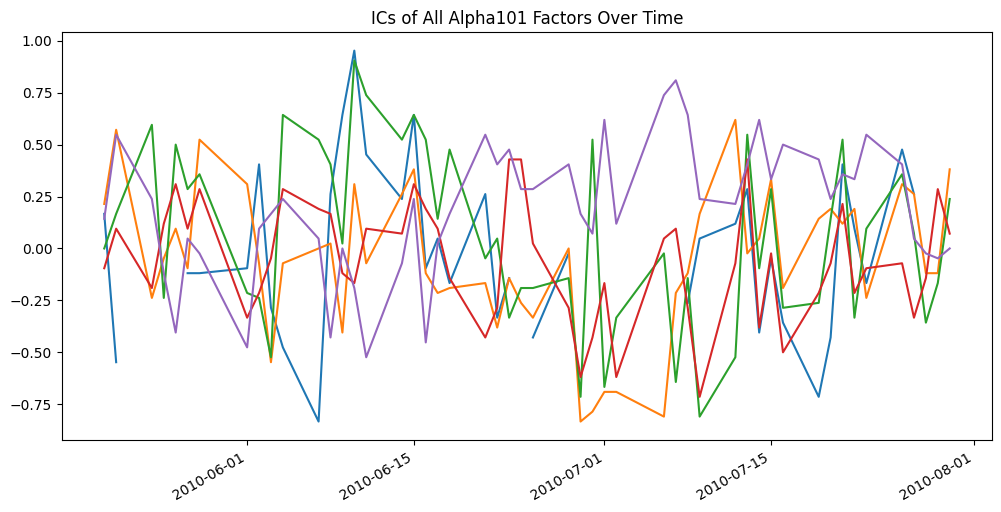

In [25]:
ic_df.iloc[1000:1050][ic_df.columns[random.sample(range(ic_df.shape[1]),5)]]\
    .plot(legend=False, 
          figsize=(12,6), 
          title='ICs of All Alpha101 Factors Over Time')

<Axes: title={'center': 'ICs of All Alpha101 Factors Over Time'}>

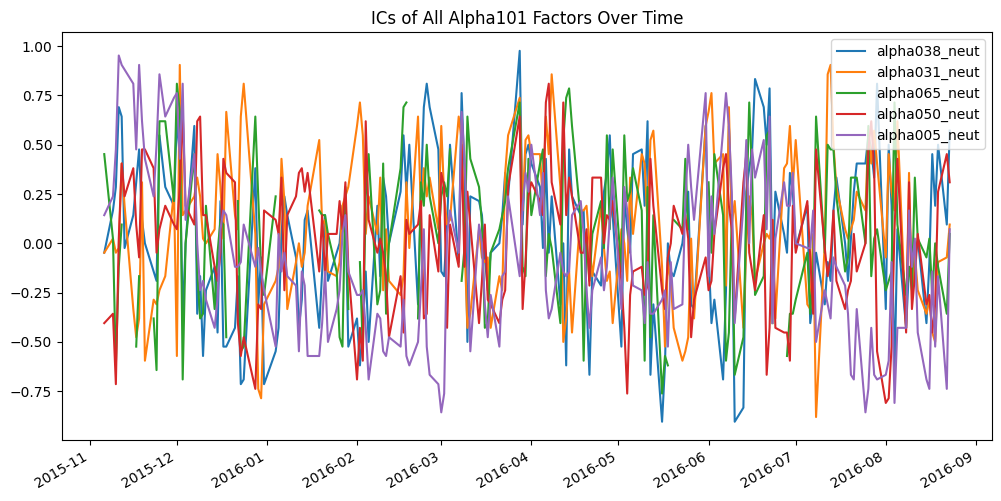

In [26]:
window = 200
start = random.randint(0, len(ic_df) - window)
sampled_rows = ic_df.iloc[start:start + window]
sampled_cols = random.sample(list(ic_df.columns), 5)

sampled_rows[sampled_cols].sort_index().plot(
    legend=True,
    figsize=(12, 6),
    title='ICs of All Alpha101 Factors Over Time'
)

Each IC series is a time series of daily correlations between the neutralized factor values and the forward returns over the 21-day horizon. It is a measure of, on each day, how well the factor's ranking predicted the cross-sectional return ranking over the next period 

Interpretation of mean ICs

| Mean IC    | Typical interpretation                  |
| ---------- | --------------------------------------- |
| > 0.05     | Very strong factor (rare)               |
| 0.02–0.05  | Good, likely tradable                   |
| 0.005–0.02 | Weak but possibly useful in combination |
| ~0         | Noise / no predictive power             |
| < 0        | Inverted signal (could short it)        |


In [27]:
def compute_ic_summary(ic_df):
    ic_summary = []
    for series in ic_df.columns:
        ic_summary.append({
            'Factor': series,
            'Mean IC': ic_df[series].mean(),
            'Std IC': ic_df[series].std(),
            'Mean to Std IC': ic_df[series].mean() / ic_df[series].std(),
            'Information ratio': ic_df[series].mean() / ic_df[series].std()
        })
    return pd.DataFrame(ic_summary)

ICs_summary = compute_ic_summary(ic_df)
display(ICs_summary)

,Factor,Mean IC,Std IC,Mean to Std IC,Information ratio
0,alpha001_neut,-0.004915,0.374007,-0.013142,-0.013142
1,alpha002_neut,0.004994,0.379976,0.013143,0.013143
2,alpha003_neut,-0.001578,0.369720,-0.004268,-0.004268
3,alpha004_neut,-0.004576,0.384899,-0.011889,-0.011889
4,alpha005_neut,-0.044847,0.388485,-0.115440,-0.115440
...,...,...,...,...,...
75,alpha095_neut,-0.166667,0.101015,-1.649916,-1.649916
76,alpha096_neut,0.008369,0.375346,0.022298,0.022298
77,alpha098_neut,-0.007786,0.378067,-0.020594,-0.020594
78,alpha099_neut,0.003323,0.367128,0.009051,0.009051


In [28]:
# Selection of top factors
ICs_summary.sort_values(by='Mean IC', ascending=False, key=abs).tail(20)
# ICs_summary.sort_values(by='Mean IC', ascending=False).tail(20)

,Factor,Mean IC,Std IC,Mean to Std IC,Information ratio
78,alpha099_neut,0.003323,0.367128,0.009051,0.009051
7,alpha008_neut,0.003094,0.399338,0.007747,0.007747
49,alpha051_neut,0.002955,0.383861,0.007697,0.007697
38,alpha039_neut,0.002830,0.395096,0.007163,0.007163
25,alpha026_neut,-0.002233,0.366424,-0.006095,-0.006095
28,alpha029_neut,-0.002212,0.387187,-0.005712,-0.005712
22,alpha023_neut,0.001794,0.387958,0.004624,0.004624
34,alpha035_neut,0.001730,0.376371,0.004596,0.004596
73,alpha092_neut,-0.001665,0.376317,-0.004426,-0.004426
16,alpha017_neut,-0.001597,0.380352,-0.004198,-0.004198


# Pruning Factors

A multi-factor strategy’s goal isn’t just maximizing each factor’s standalone IC.

It’s about combining diverse, weakly correlated signals so the aggregate IC (or portfolio IR) is more stable.

*Key points:*

- Low correlation / orthogonal ICs → smoother combined performance.
- Factor rotation or pattern recognition (e.g., regime detection via ML or macro states) helps allocate weight dynamically.
- A few moderate-IC but complementary factors can outperform one large-IC factor that decays quickly.
- Think “ensemble learning” — robustness through diversification, not dominance.


> So yes, non-overlapping, compensating IC patterns across factors are often more valuable than one big IC

will remove correlated factors

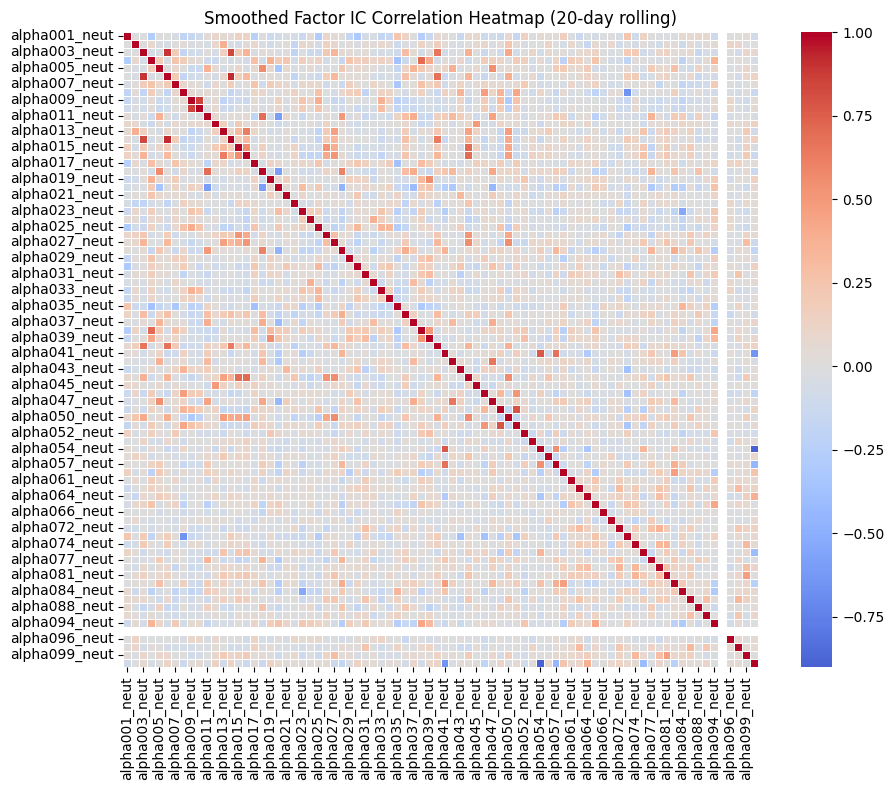

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Smooth ICs using rolling mean (e.g. 20-day)
ic_smooth = ic_df.rolling(20, min_periods=5).mean()

# Compute correlation across factors using smoothed ICs
corr = ic_smooth.corr()

# Optional: filter out weak correlations
# corr = corr[abs(corr) >= 0.1]

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    annot=False, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, square=True
)
plt.title("Smoothed Factor IC Correlation Heatmap (20-day rolling)")
plt.tight_layout()
plt.show()


In [30]:
def prune_redundant_factors(ic_df, corr_threshold=0.8, skip_factors=None):
    """
    Remove redundant factors that are highly correlated.
    Keeps the one with higher mean IC when |corr| > threshold.

    Parameters
    ----------
    ic_df : pd.DataFrame
        DataFrame of IC values (index = dates, columns = factors)
    corr_threshold : float
        Correlation threshold to treat factors as redundant

    Returns
    -------
    pd.DataFrame
        Filtered IC DataFrame with redundant factors removed
    """
    # smoothed ICs
    ic_smooth = ic_df.rolling(20, min_periods=5).mean()
    corr = ic_smooth.corr()
    mean_ic = ic_df.mean()
    to_drop = set()
    corr_columns = corr.columns.tolist()
    if skip_factors is not None:
        corr_columns = [col for col in corr.columns if col not in skip_factors]


    # Only consider upper triangle to avoid double-counting
    for i in range(len(corr_columns)):
        for j in range(i+1, len(corr_columns)):
            col_i = corr_columns[i]
            col_j = corr_columns[j]
            if abs(corr.loc[col_i, col_j]) > corr_threshold:
                # Drop factor with smaller mean IC
                drop = col_j if mean_ic[col_i] >= mean_ic[col_j] else col_i
                to_drop.add(drop)

    return ic_df.drop(columns=list(to_drop))


In [31]:
ic_df.dropna(how='all', axis=1).isnull().sum().sort_values().tail(10)

alpha023_neut     438
alpha099_neut     466
alpha027_neut     507
alpha062_neut     533
alpha078_neut     565
alpha046_neut     686
alpha065_neut     749
alpha061_neut     841
alpha021_neut    1315
alpha095_neut    4842
dtype: int64

In [32]:
ic_df2 = prune_redundant_factors(ic_df, 
                                 corr_threshold=.5,
                                 skip_factors=['alphas096'])
ic_df2.shape

(4844, 57)

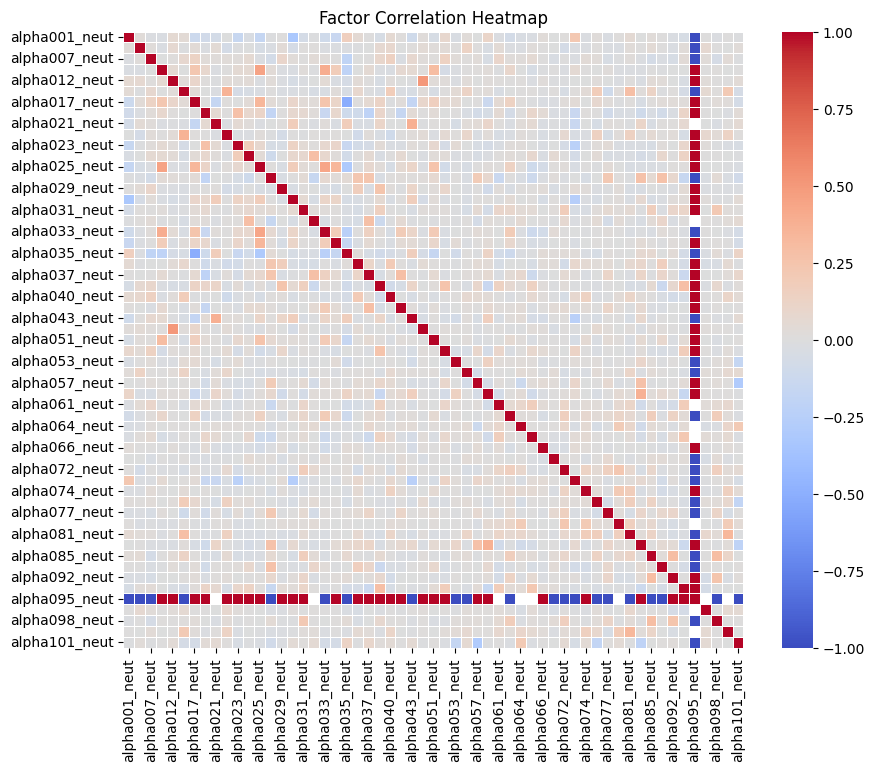

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(ic_df2.corr(), annot=False, 
    cmap="coolwarm", center=0,
    linewidths=0.5,fmt=".2f")
plt.title("Factor Correlation Heatmap")
plt.show()

In [34]:
ic_df2.shape

(4844, 57)

In [35]:
# Save pruned factors to a text file
with open('../data/pruned_factors.txt', 'w') as f:
    f.write('\n'.join(ic_df2.columns.to_list()))

> get pruned factors df

In [36]:
df = pd.read_csv('../data/factor_table_neut_v3.csv')
pruned_factors = []
with open('../data/pruned_factors.txt', 'r') as f:
    pruned_factors = f.read().splitlines()

In [37]:
factors_df = df[['Date', 'Ticker'] + pruned_factors]

In [38]:
factors_df.shape

(38752, 59)

# Fit models on alphas

## Create 'Naive' baseline with equal weighted for all factors

In [39]:
## might be useful to get base line

# build composite alpha function  builds a composite alpha column (the final signal) from the ICs of each factor combined with its weightage
# Weighting is meant to combine factors so that more predictive factors contribute more to the composite alpha
# The coding here uses absolute IC weighting and has parameterisation for equal weighting
def build_composite_alpha(table_neut, factor_cols, ic_summary=None, weighted=False):
    df = table_neut.copy()
    
    # Define weights
    if weighted and ic_summary is not None:
        weights = np.array([ic_summary.get(f, 0.0) for f in factor_cols])
        weights /= np.sum(np.abs(weights)) + 1e-12
    else:
        weights = np.ones(len(factor_cols)) / len(factor_cols)
    
    # Weighted combination (row-wise dot product)
    df['composite_alpha'] = df[factor_cols].fillna(0).dot(weights)
    
    # Z-score within each date
    df['composite_alpha'] = (df.groupby('Date')['composite_alpha'].transform(lambda x: (x - x.mean()) / (x.std() + 1e-9)))
    return df

In [40]:
baseline_df =\
build_composite_alpha(factors_df, pruned_factors, 
                      ic_summary=None,
                      weighted=False)

In [41]:
# baseline_df
baseline_df["rank"] = baseline_df.groupby("Date")["composite_alpha"].rank(method="first")
baseline_df["pct_rank"] = baseline_df.groupby("Date")["rank"].transform(lambda x: x / x.max())

# Buy if top half, Sell if bottom half
baseline_df["signal"] = (baseline_df["pct_rank"] > 0.5).astype(int) * 2 - 1
# gives 1 for buy, -1 for sell

# add forward returns
baseline_df = pd.merge(baseline_df, 
         df[['Date', 'Ticker', 'forward_return']], 
         on=['Date', 'Ticker'])
baseline_df['strategy_return'] = baseline_df['signal'] * baseline_df['forward_return']

In [42]:
baseline_df['gross_return'] = baseline_df['strategy_return'] +1

strategy_returns = baseline_df.groupby(["Date", "Ticker"])["gross_return"].mean() ** (1 / HORIZON)

In [43]:
naive_daily_return = baseline_df.groupby('Date')['gross_return'].mean()

## Create Long only

In [44]:
baseline_df['passive_gross_return'] = baseline_df['forward_return'] + 1

In [45]:
longonly_returns = baseline_df[['Date', 'Ticker', 'passive_gross_return']]\
                    .pivot(index='Date', columns='Ticker', values='passive_gross_return')


In [190]:
longonly_daily_return = (longonly_returns ** (1 / HORIZON)).mean(axis=1)

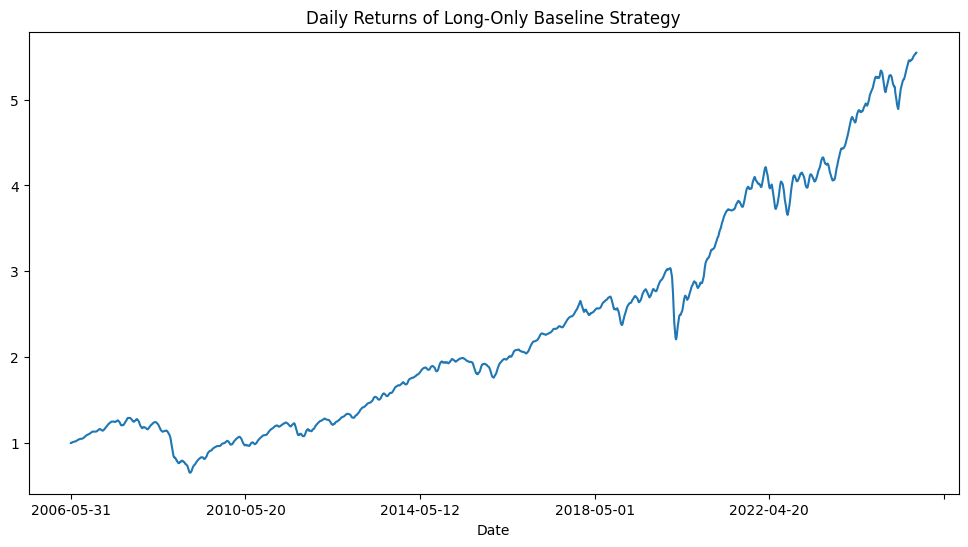

In [191]:
longonly_daily_return.cumprod().plot(figsize=(12,6), title='Daily Returns of Long-Only Baseline Strategy');

## Create Xgboost model

{'colsample_bytree': 0.7, 'learning_rate': 0.003, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.7}

### Random search
Best parameters found:
{'subsample': 0.8, 'n_estimators': 1500, 'max_depth': 3, 'learning_rate': 0.003, 'colsample_bytree': 0.8}
Best cross-validation score: 0.0029

In [48]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

In [144]:
def get_long_short_signals(df, frac=0.25):
    """
    Generate dollar-neutral long/short signals from predicted scores.
    
    Parameters
    ----------
    lgb_df : DataFrame
        Columns = ['Date', 'Ticker', 'pred']
    frac : float
        Fraction of universe to long and short (e.g., 0.25 = top/bottom 25%)
    total_cap : float
        Total notional exposure (long + short)
    
    Returns
    -------
    signal_df : DataFrame
        Index = Date, Columns = Ticker, values = scaled signals
    """
    pred_pivot = df.pivot(index='Date', columns='Ticker', values='pred')
    n = pred_pivot.shape[1]

    num_longs = int(np.floor(frac * n))
    num_shorts = int(np.floor(frac * n))

    # argsort twice to get ranks fast
    ranks = pred_pivot.to_numpy().argsort(axis=1).argsort(axis=1)
    signals = np.zeros_like(ranks, dtype=float)

    # Mark longs and shorts by rank index
    signals[ranks >= n - num_longs] = 1
    signals[ranks < num_shorts] = -1

    # Scale for dollar neutrality
    scale = n / (num_longs+ num_shorts)
    signals *= scale

    signal_df = pd.DataFrame(signals, index=pred_pivot.index, columns=pred_pivot.columns).stack().values
    return signal_df

# lgb_df['signal'] = get_long_short_signals(lgb_df, frac=0.25)

In [50]:
xg_df = baseline_df.drop(columns=['composite_alpha', 'rank', 'pct_rank', 'signal', 'strategy_return']).copy()
factor_cols = [c for c in xg_df.columns if c.startswith("alpha")]
X = xg_df[factor_cols]
y = xg_df["forward_return"]

In [51]:
validation_splitter = 31000 - 3880
test_splitter = 31000

X_train = X.iloc[:validation_splitter]
X_val = X.iloc[validation_splitter:test_splitter]
X_test = X.iloc[test_splitter:]

y_train = y.iloc[:validation_splitter]
y_val = y.iloc[validation_splitter:test_splitter]
y_test = y.iloc[test_splitter:]

print(f"Train set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTarget shapes:")
print(f"y_train: {y_train.shape}")
print(f"y_val: {y_val.shape}")
print(f"y_test: {y_test.shape}")

Train set: (27120, 57)
Validation set: (3880, 57)
Test set: (7752, 57)

Target shapes:
y_train: (27120,)
y_val: (3880,)
y_test: (7752,)


In [52]:
import json
import os

In [53]:
print("=" * 60)
print("PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters")
print("=" * 60)

if os.path.exists('../data/best_xgb_params.json'):
    with open('../data/best_xgb_params.json', 'r') as f:
        loaded_params = json.load(f)
    best_params = loaded_params
else:
    param_distributions = {
        'n_estimators': [1000, 1500, 1800, 2000],
        'learning_rate': [0.003, 0.005, 0.01],
        'max_depth': [3, 5, 7, None],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.7, 0.8, 0.9],
    }
    # Initialize base model
    base_model = xgb.XGBRegressor(random_state=RANDOM_SEED, objective='reg:squarederror')
    # Set up RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=60,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_SEED
    )
    # Fit on full training set
    print("Starting randomized search on training set...")
    random_search.fit(X_train, y_train)

    print("\nBest parameters found:")
    print(random_search.best_params_)
    print(f"Best cross-validation score: {-random_search.best_score_:.4f}")

    # Get best parameters
    best_params = random_search.best_params_

    # Save to JSON  
    with open('../data/best_xgb_params.json', 'w') as f:
        json.dump(best_params, f, indent=4)

PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters


In [54]:
# ============================================
# PHASE 2: Walk-Forward with Periodic Retraining (Rolling Window + Warm Start)
# ============================================
retrain_frequency = HORIZON * len(tickers) # Retrain every HORIZON samples e.g. 1 month
window_size = HORIZON * len(tickers)  # Add last 1 month data rows for training
predictions = []
current_model = None
initial_train_size = len(X_train)

print(f"\nRetraining every {retrain_frequency} samples")
print(f"Using rolling window of {window_size} samples")

for i in tqdm(range(initial_train_size, len(X))):
    # Retrain when needed
    if (i - initial_train_size) % retrain_frequency == 0 or current_model is None:
        # Get the latest window_size rows for training
        start_idx = max(0, i - window_size)
        X_train_wf = X.iloc[:i].copy()
        y_train_wf = y.iloc[:i].copy()

        if current_model is None:
            # First iteration: train from scratch
            current_model = xgb.XGBRegressor(
                **best_params, 
                random_state=RANDOM_SEED, 
                objective='reg:squarederror'
            )
            current_model.fit(X_train_wf, y_train_wf)
            print(f"Initial model trained at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
        else:
            # Subsequent iterations: warm start from previous model
            current_model.fit(
                X_train_wf, 
                y_train_wf,
                xgb_model=current_model.get_booster()  # Warm start from previous model
            )
            print(f"Model updated (warm start) at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
    
    # Predict using current model
    X_test_wf = X.iloc[i:i+1].copy()
    pred = current_model.predict(X_test_wf)[0]
    predictions.append(pred)
    
    # Progress update
    if (i - initial_train_size + 1) % 250 == 0:
        print(f"Processed {i - initial_train_size + 1}/{len(X) - initial_train_size} predictions")

print(f"\nCompleted {len(predictions)} walk-forward predictions")

# ============================================
# COMBINE PREDICTIONS
# ============================================
# Initial model predictions on training set
model_initial = xgb.XGBRegressor(**best_params, random_state=RANDOM_SEED, objective='reg:squarederror')
model_initial.fit(X_train, y_train)
train_predictions = model_initial.predict(X_train)

# Split walk-forward predictions into val and test
val_predictions = predictions[:len(X_val)]
test_predictions = predictions[len(X_val):]

# Combine all predictions
xg_df["pred"] = np.nan
xg_df.loc[X_train.index, "pred"] = train_predictions
xg_df.loc[X_val.index, "pred"] = val_predictions
xg_df.loc[X_test.index, "pred"] = test_predictions




Retraining every 160 samples
Using rolling window of 160 samples


  0%|          | 26/11632 [00:03<16:31, 11.70it/s] 

Initial model trained at sample 1 with 27120 rows


  2%|▏         | 197/11632 [00:06<06:28, 29.43it/s] 

Model updated (warm start) at sample 161 with 27280 rows


...

Processed 11500/11632 predictions


 99%|█████████▉| 11529/11632 [09:22<00:34,  2.97it/s]

Model updated (warm start) at sample 11521 with 38640 rows


100%|██████████| 11632/11632 [09:23<00:00, 20.64it/s]



Completed 11632 walk-forward predictions


In [130]:
xg_df

,Date,Ticker,alpha001_neut,alpha002_neut,alpha007_neut,alpha010_neut,alpha012_neut,alpha016_neut,alpha017_neut,alpha020_neut,...,alpha096_neut,alpha098_neut,alpha099_neut,alpha101_neut,forward_return,gross_return,passive_gross_return,pred,signal,strategy_return
0,2006-05-31,XLB,-6.273904e-08,3.687601e-08,1.300256e-09,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.339762,0.000000,1.306299,-0.010310,0.979381,0.989690,0.018099,2.0,-0.020619
1,2006-05-31,XLE,-6.095771e-08,-4.057613e-08,6.733587e-09,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.056572,0.000000,0.647825,0.019197,1.038393,1.019197,0.018745,2.0,0.038393
2,2006-05-31,XLF,7.952301e-08,5.141223e-08,4.357579e-09,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.442360,0.000000,-0.594123,-0.013329,1.000000,0.986671,0.009809,0.0,-0.000000
3,2006-05-31,XLI,-3.742537e-09,1.240414e-08,2.098025e-09,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.454851,0.000000,-0.887963,-0.011186,0.977628,0.988814,0.018401,2.0,-0.022372
4,2006-05-31,XLK,5.841323e-08,-5.774710e-08,4.287676e-09,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.083218,0.000000,-0.081176,-0.016362,0.967276,0.983638,0.017100,2.0,-0.032724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38747,2025-08-29,XLI,-7.294731e-01,6.166305e-01,-3.665656e-01,0.637624,0.585879,0.407313,1.142096,0.740756,...,-2.340901,-0.695970,2.141052,-0.572599,0.028608,1.057216,1.028608,0.011926,2.0,0.057216
38748,2025-08-29,XLK,-3.457390e-01,1.330970e+00,7.924610e-02,1.722658,1.735406,-0.262326,0.760952,1.702373,...,0.053098,-0.030981,-0.316592,-0.414376,0.086306,0.827388,1.086306,0.001648,-2.0,-0.172612
38749,2025-08-29,XLP,1.572887e+00,-2.182253e-01,2.245893e+00,-0.564087,-0.617715,-2.471701,0.253383,0.113052,...,0.524463,-1.826693,-1.306754,0.834318,-0.021602,1.000000,0.978398,0.009865,0.0,-0.000000
38750,2025-08-29,XLU,-1.164612e+00,-7.421264e-01,-8.562448e-01,-0.592595,-0.455644,1.002860,-0.058503,-0.912733,...,0.423734,0.386691,0.129381,-1.121745,0.044705,1.089411,1.044705,0.029379,2.0,0.089411


In [159]:
# ============================================
# GENERATE SIGNALS & RETURNS
# ============================================
# Rank predictions per date → long/short
xg_df["signal"] = get_long_short_signals(xg_df, frac=1/8)

xg_df['strategy_return'] = xg_df['signal'] * xg_df['forward_return']
xg_df['gross_return'] = xg_df['strategy_return'] + 1


print(f"\n{'='*60}")
print("Performance Metrics")
print(f"{'='*60}")
print(f"Train period sharpe: {xg_df.loc[X_train.index, 'strategy_return'].mean() / xg_df.loc[X_train.index, 'strategy_return'].std() * np.sqrt(252):.3f}")
print(f"Test period sharpe: {xg_df.loc[X_test.index, 'strategy_return'].mean() / xg_df.loc[X_test.index, 'strategy_return'].std() * np.sqrt(252):.3f}")


Performance Metrics
Train period sharpe: 1.541
Test period sharpe: -0.163


In [74]:
## After RandomizedSearchCV
# best_params = random_search.best_params_

## Save to JSON  
# with open('../data/best_xgb_params.json', 'w') as f:
#     json.dump(best_params, f, indent=4)

## Create LGB Model

Best parameters found:
{'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 2000, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.003, 'colsample_bytree': 0.7}
### Random search
Best parameters: {'subsample': 1.0, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 800, 'min_child_samples': 50, 'max_depth': 1, 'learning_rate': 0.001, 'colsample_bytree': 0.7}


In [57]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split

In [58]:


lgb_df = baseline_df.drop(columns=['composite_alpha', 'rank', 'pct_rank', 'signal', 'strategy_return']).copy()


In [59]:
print("=" * 60)
print("PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters")
print("=" * 60)

if os.path.exists('../data/best_lgb_params.json'):
    with open('../data/best_lgb_params.json', 'r') as f:
        loaded_params = json.load(f)
    best_params = loaded_params
else:
    param_distributions = {
    'n_estimators': [200, 300, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10, -1],  # -1 means no limit
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20, 30],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1.0],  # L1 regularization
    'reg_lambda': [0, 0.01, 0.1, 1.0],  # L2 regularization
    }

    # Base model
    base_model = lgb.LGBMRegressor(random_state=RANDOM_SEED,objective='regression',metric='rmse',verbosity=-1, force_col_wise=True  # Faster for wide datasets
    )
    # Randomized search
    print("Starting LightGBM hyperparameter tuning...")
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=60,
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_SEED
    )
    random_search.fit(X_train, y_train)

    best_params = random_search.best_params_
    print(f"\nBest parameters: {best_params}")
    print(f"Best CV score: {-random_search.best_score_:.6f}")
    with open(f'../data/best_lgb_params.json', 'w') as f:
        json.dump(best_params, f, indent=4)

PHASE 1: Initial Hyperparameter Tuning or Loading Saved Parameters


In [60]:
# ============================================
# PHASE 2: Walk-Forward with Periodic Retraining (Expanding Window)
# ============================================
retrain_frequency = HORIZON * len(tickers)  # Retrain every HORIZON samples
predictions = []
current_model = None
initial_train_size = len(X_train)

print(f"\nRetraining every {retrain_frequency} samples")
print(f"Using expanding window")

for i in tqdm(range(initial_train_size, len(X))):
    # Retrain when needed
    if (i - initial_train_size) % retrain_frequency == 0 or current_model is None:
        # Expanding window: train from start to current position
        X_train_wf = X.iloc[:i].copy()
        y_train_wf = y.iloc[:i].copy()
        
        if current_model is None:
            # First iteration: train from scratch
            current_model = lgb.LGBMRegressor(
                **best_params,
                random_state=RANDOM_SEED,
                objective='regression',
                metric='rmse',
                verbosity=-1,
                force_col_wise=True
            )
            current_model.fit(X_train_wf, y_train_wf)
            print(f"\nInitial model trained at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
        else:
            # Subsequent iterations: continue training from previous model
            # LightGBM's warm start: init_model parameter
            current_model.fit(
                X_train_wf,
                y_train_wf,
                init_model=current_model  # Warm start from previous model
            )
            print(f"\nModel updated (warm start) at sample {i - initial_train_size + 1} with {len(X_train_wf)} rows")
    
    # Predict using current model
    X_test_wf = X.iloc[i:i+1].copy()
    pred = current_model.predict(X_test_wf)[0]
    predictions.append(pred)
    
    # Progress update
    if (i - initial_train_size + 1) % 250 == 0:
        print(f"Processed {i - initial_train_size + 1}/{len(X) - initial_train_size} predictions")

print(f"\nCompleted {len(predictions)} walk-forward predictions")


Retraining every 160 samples
Using expanding window


  0%|          | 1/11632 [00:00<2:02:34,  1.58it/s]


Initial model trained at sample 1 with 27120 rows


  1%|▏         | 161/11632 [00:01<01:41, 113.39it/s]


Model updated (warm start) at sample 161 with 27280 rows
Processed 250/11632 predictions


...

Processed 11500/11632 predictions


100%|█████████▉| 11577/11632 [07:18<00:04, 12.24it/s]


Model updated (warm start) at sample 11521 with 38640 rows


100%|██████████| 11632/11632 [07:18<00:00, 26.50it/s]


Completed 11632 walk-forward predictions


In [61]:
# ============================================
# COMBINE PREDICTIONS
# ============================================
# Initial model predictions on training set
model_initial = lgb.LGBMRegressor(**best_params, random_state=RANDOM_SEED,objective='regression', metric='rmse')
model_initial.fit(X_train, y_train)
train_predictions = model_initial.predict(X_train)

# Split walk-forward predictions into val and test
val_predictions = predictions[:len(X_val)]
test_predictions = predictions[len(X_val):]

# Combine all predictions
lgb_df["pred"] = np.nan
lgb_df.loc[X_train.index, "pred"] = train_predictions
lgb_df.loc[X_val.index, "pred"] = val_predictions
lgb_df.loc[X_test.index, "pred"] = test_predictions


In [163]:
# ============================================
# GENERATE SIGNALS & RETURNS
# ============================================
# Rank predictions per date → long/short
lgb_df["signal"] = get_long_short_signals(lgb_df, frac=1/4)

lgb_df['strategy_return'] = lgb_df['signal'] * lgb_df['forward_return']
lgb_df['gross_return'] = lgb_df['strategy_return'] + 1


print(f"\n{'='*60}")
print("Performance Metrics")
print(f"{'='*60}")
print(f"Train period sharpe: {lgb_df.loc[X_train.index, 'strategy_return'].mean() / lgb_df.loc[X_train.index, 'strategy_return'].std() * np.sqrt(252):.3f}")
print(f"Test period sharpe: {lgb_df.loc[X_test.index, 'strategy_return'].mean() / lgb_df.loc[X_test.index, 'strategy_return'].std() * np.sqrt(252):.3f}")


Performance Metrics
Train period sharpe: 0.909
Test period sharpe: 0.103


# Evaluation

## Naive cum returns

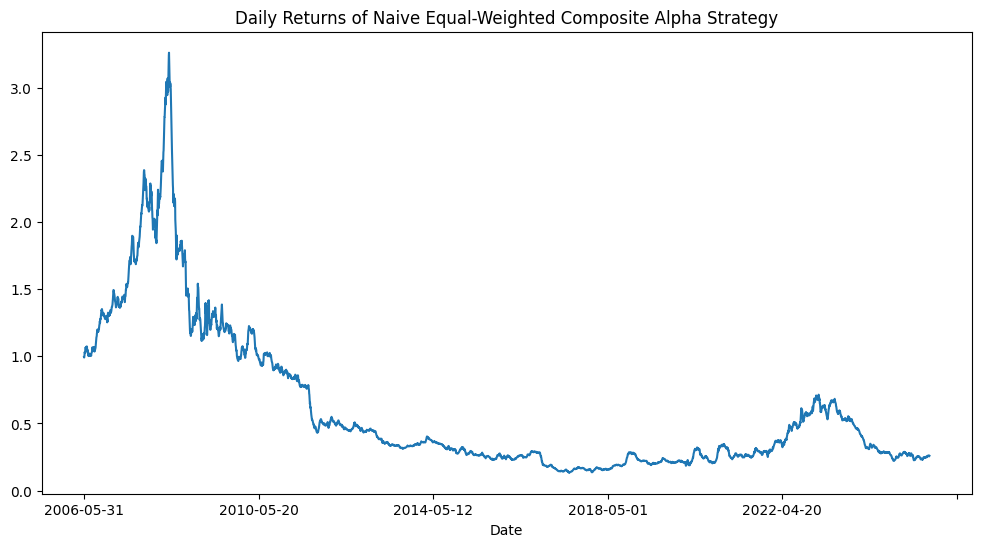

In [164]:
naive_daily_return.cumprod().plot(figsize=(12,6), title='Daily Returns of Naive Equal-Weighted Composite Alpha Strategy');

## Long only returns

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


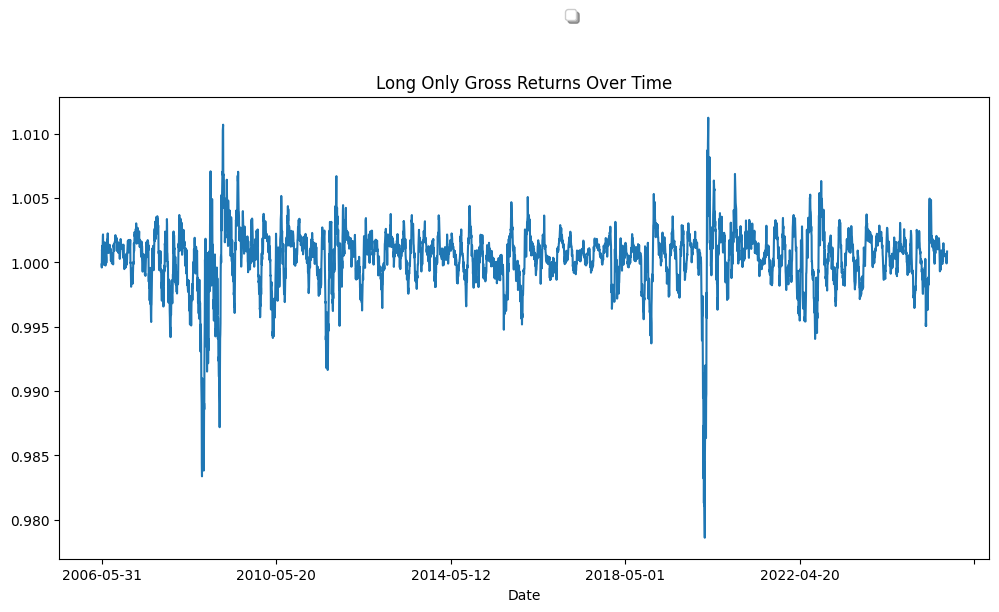

In [165]:
ax = longonly_daily_return.plot(figsize=(12,6), 
                             title='Long Only Gross Returns Over Time')

(
    ax
    .legend(
        loc="lower center",
        bbox_to_anchor = (0.55, 1.15),
        ncol=4,
        shadow=True
    )
);

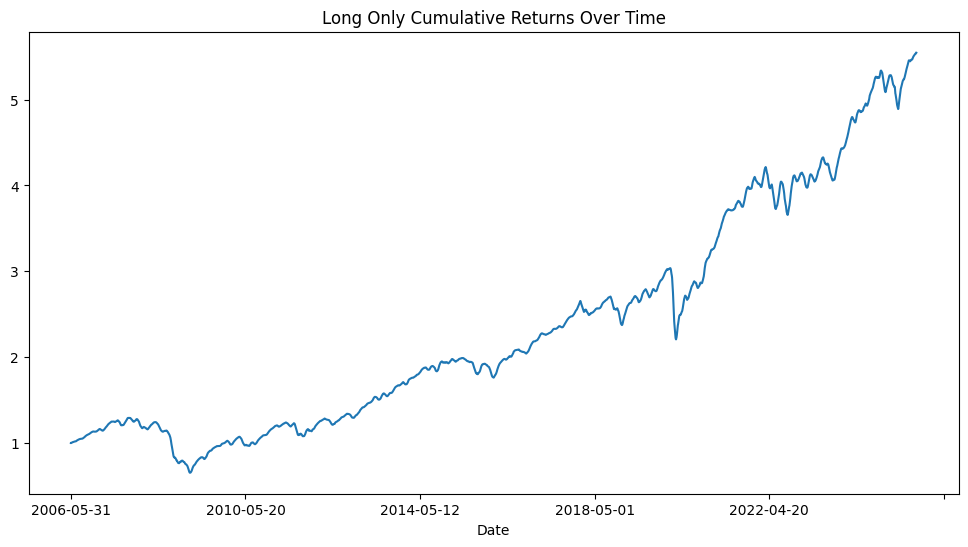

In [166]:
long_only_cum_returns = \
longonly_daily_return.cumprod()
long_only_cum_returns.plot(figsize=(12,6), title='Long Only Cumulative Returns Over Time');

## Xgboost

<Axes: title={'center': 'XGBoost Strategy Cumulative Returns Over Time'}, xlabel='Date'>

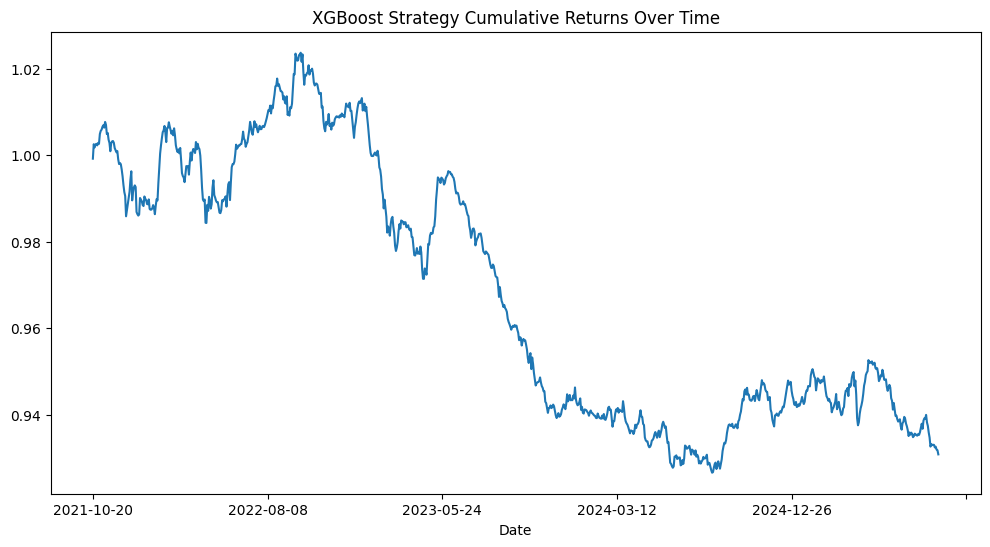

In [167]:
# xg_strategy_returns.iloc[splitter//len(tickers):].plot(figsize=(12,6), title='XGBoost Strategy Daily Returns Over Time')
xg_gross_returns =\
      xg_df.iloc[test_splitter:].groupby('Date')['gross_return'].mean() ** (1 / HORIZON)
xg_cum_returns =\
      xg_gross_returns.cumprod()

xg_cum_returns.plot(figsize=(12,6), title='XGBoost Strategy Cumulative Returns Over Time')

## LightGB Model


<Axes: title={'center': 'LightGBM Strategy Cumulative Returns Over Time'}, xlabel='Date'>

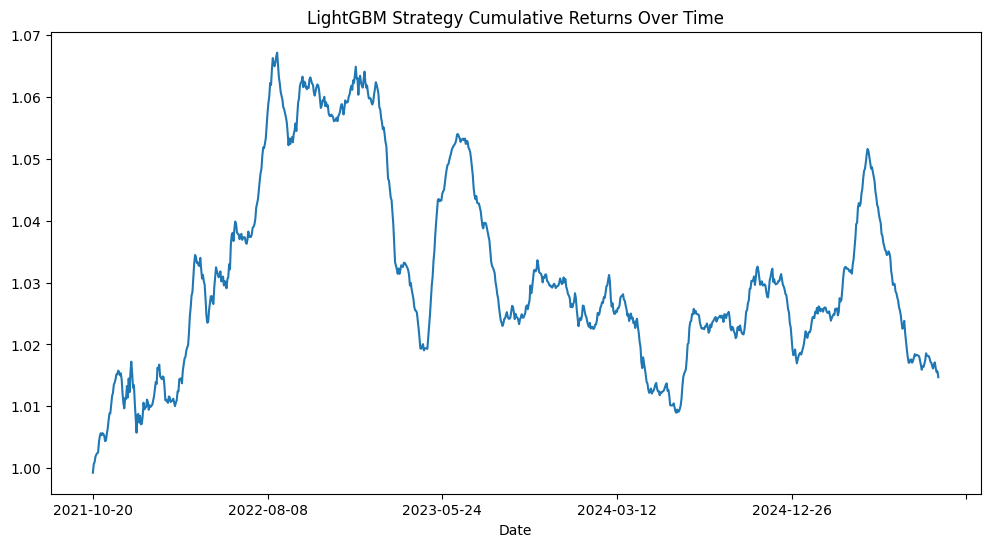

In [168]:
lg_gross_returns =\
      lgb_df.iloc[test_splitter:].groupby('Date')['gross_return'].mean() ** (1 / HORIZON)
lg_cum_returns =\
      lg_gross_returns.cumprod()
lg_cum_returns.plot(figsize=(12,6), title='LightGBM Strategy Cumulative Returns Over Time')

In [189]:
a

Date
2006-05-31    0.999843
2006-06-01    0.999449
2006-06-02    1.000438
2006-06-05    1.001135
2006-06-06    1.002438
                ...   
2025-08-25    5.538055
2025-08-26    5.537634
2025-08-27    5.539569
2025-08-28    5.541907
2025-08-29    5.546626
Length: 4844, dtype: float64

In [ ]:
a = longonly_daily_return.cumprod()
a.index = pd.to_datetime(a.index)
a.iloc[-1] **((a.index[-1]-a.index[0]).days/365) -1

213894396988535.06

In [ ]:

def get_long_short_signals(df, frac=0.25):
    """
    Generate dollar-neutral long/short signals from predicted scores.
    
    Parameters
    ----------
    lgb_df : DataFrame
        Columns = ['Date', 'Ticker', 'pred']
    frac : float
        Fraction of universe to long and short (e.g., 0.25 = top/bottom 25%)
    total_cap : float
        Total notional exposure (long + short)
    
    Returns
    -------
    signal_df : DataFrame
        Index = Date, Columns = Ticker, values = scaled signals
    """
    pred_pivot = df.pivot(index='Date', columns='Ticker', values='pred')
    n = pred_pivot.shape[1]

    num_longs = int(np.floor(frac * n))
    num_shorts = int(np.floor(frac * n))

    # argsort twice to get ranks fast
    ranks = pred_pivot.to_numpy().argsort(axis=1).argsort(axis=1)
    signals = np.zeros_like(ranks, dtype=float)

    # Mark longs and shorts by rank index
    signals[ranks >= n - num_longs] = 1
    signals[ranks < num_shorts] = -1

    # Scale for dollar neutrality
    scale = n / (2 * (num_longs + num_shorts))
    signals *= scale

    signal_df = pd.DataFrame(signals, index=pred_pivot.index, columns=pred_pivot.columns)
    signal_df.sum(axis=1)

In [180]:
a.iloc[-1]

1.0147070559794353

In [201]:
def get_sharpe_ratio(gross_returns, window=1):
    ret = gross_returns - 1
    avg_ret = ret.mean()
    std_ret = ret.std()
    sharpe_ratio = avg_ret / std_ret * np.sqrt(252)
    return sharpe_ratio

def get_cagr(daily_returns, periods_per_year=365):
    cumulative_return = daily_returns.cumprod()
    cumulative_return.index = pd.to_datetime(cumulative_return.index)
    cagr = (cumulative_return.iloc[-1]) ** (periods_per_year / (cumulative_return.index[-1] - cumulative_return.index[0]).days) - 1
    return cagr

dct = {
    'naive': naive_daily_return,
    'long_only': longonly_daily_return,
    'xg': xg_gross_returns,
    'lg': lg_gross_returns
}



compiled_returns = pd.Series({k: get_cagr(v) for k, v in dct.items()}).to_frame("CAGR")
compiled_sharpe = pd.Series({ k: get_sharpe_ratio(v) for k, v in dct.items()}).to_frame("Sharpe Ratio")

display(compiled_returns)
display(compiled_sharpe)

,CAGR
naive,-0.067675
long_only,0.093025
xg,-0.018406
lg,0.003789


,Sharpe Ratio
naive,-0.239486
long_only,2.424415
xg,-0.828648
lg,0.255433


# Learning to rank

LTR is a supervised step that replaces or refines the combination step. It involves training a model that ranks stocks by expected future return. Instead of predicting exact returns, it learns an ordering of stocks that maximizes predictive power. LTR can capture non-linear interactions between factors that IC weighting or simple averaging cannot. It’s particularly useful when you have many factors or some factors are highly correlated.

Inputs: 
- Neutralised factor columns (or other features) per stock per date
- Forward returns (target variable)

Outputs:
- A predicted ranking score for each stock per date, essentially a refined composite alpha column like in the traditional pipeline

How it differs from the traditional pipeline

| Step                 | Approach                                                   | Output                                  |
| -------------------- | ---------------------------------------------------------- | --------------------------------------- |
| Equal / IC weighting | Linear combination of factors                              | Composite alpha                         |
| Learning to Rank     | Model (e.g., XGBoost, LightGBM) trained to predict ranking | Refined composite alpha / ranking score
 |


The implementation of RankNet, ListNet, and ListMLE differ in how the input data is constructed and in the loss functions used, the way the model handles input data, and how it processes the output.

**LTR Network**

- Two hidden layers (width tunable), dropout, ReLU activations
- Acts as a score generator: it takes features (neutralised factors) as input and outputs a scalar score per stock
- This stays the same regardless of which LTR method is used

**RankNet, ListNet, ListMLE**

Input processing

| Method                 | Input format                                   | Description                                                                                                                                                   |
| ---------------------- | ---------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **RankNet (pairwise)** | Pairs of stocks `(i, j)` for the same date     | Predicts probability that `i` beats `j` in forward return. Loss compares predicted pairwise order vs actual order.                                             |
| **ListNet (listwise)** | Entire cross-section (list of stocks per date) | Computes a probability distribution over the list (softmax over predicted scores and targets). Loss is cross-entropy between predicted and true distributions. |
| **ListMLE (listwise)** | Entire cross-section (list of stocks per date) | Uses the likelihood of the observed ranking; sorts targets descending, computes log-likelihood of predicted ordering.                                         Loss function
 |


| Method      | Type     | Description                                                                                               |
| ----------- | -------- | --------------------------------------------------------------------------------------------------------- |
| **RankNet** | Pairwise | Compares all pairs of stocks. Encourages the network to give higher scores to stocks with higher returns. |
| **ListNet** | Listwise | Considers the entire list of stocks simultaneously, modeling probability distributions over rankings.     |
| **ListMLE** | Listwise | Maximizes the likelihood of the observed ranking over the list.                                           |
